In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Data Analytics & Data Science\NetMax Technologies\employee_data.csv")
df.head()

,EmployeeID,Name,Age,Department,Salary,YearsOfService
0,1.0,John Smith,34.0,IT,75000.0,5.0
1,NaN,NaN,28.0,HR,60000.0,3.0
2,3.0,Michael Brown,NaN,Sales,NaN,2.0
3,4.0,Sophia Davis,45.0,Marketing,80000.0,NaN
4,NaN,NaN,36.0,NaN,65000.0,4.0


In [3]:
# dropping unnecessary columns
df.drop(columns=["EmployeeID", "Name"], inplace=True)

In [4]:
# checking null values
df.isnull().sum()

Age               129
Department        125
Salary            182
YearsOfService    184
dtype: int64

In [5]:
# handling null values with mean median and mode
df["Age"] = df["Age"].fillna(df["Age"].mode()[0])
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())
df["YearsOfService"] = df["YearsOfService"].fillna(df["YearsOfService"].mean())


In [6]:
df.head()

,Age,Department,Salary,YearsOfService
0,34.0,IT,75000.000000,5.00000
1,28.0,HR,60000.000000,3.00000
2,27.0,Sales,69402.515723,2.00000
3,45.0,Marketing,80000.000000,3.96519
4,36.0,IT,65000.000000,4.00000


In [7]:
# converting float data to int for easy calculations
df["Salary"] = df["Salary"].astype(int)
df["YearsOfService"] = df["YearsOfService"].astype(int)
df["Age"] = df["Age"].astype(int)

In [8]:
df.head()

,Age,Department,Salary,YearsOfService
0,34,IT,75000,5
1,28,HR,60000,3
2,27,Sales,69402,2
3,45,Marketing,80000,3
4,36,IT,65000,4


In [9]:
# handling categorical data
label = LabelEncoder()
df["Department"] = label.fit_transform(df["Department"])


In [10]:
# feature selection
x = df.drop(columns=["Salary"])
y = df["Salary"]

In [11]:
# data splitting

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [12]:
# scaling the data as well

from matplotlib import scale


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) #preventing data leakage

In [ ]:
# 1st using the linear regressor


model_linear_regression = LinearRegression()

model_linear_regression.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred_linear_regression = model_linear_regression.predict(x_test)
r2_score_linear_regression = r2_score(y_test, y_pred_linear_regression)
print(f"R2 Score with Linear Regressor: {r2_score_linear_regression:.2f}")

R2 Score with Linear Regressor: -0.01


In [20]:
# using random forest regressor
model_random_forest = RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

model_random_forest.fit(x_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred_random_forest = model_random_forest.predict(x_test)
r2_score_random_forest = r2_score(y_test,y_pred_random_forest)
print(f"R2 Score with Random Forest: {r2_score_random_forest:.2f}")

R2 Score with Random Forest: 0.38


In [24]:
# now using grid search and xgboost
best_para = {"max_depth" : [2,4,5,7], "n_estimators": [200,250,300,350]}

model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model,
                           param_grid=best_para,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [2, 4, ...], 'n_estimators': [200, 250, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [25]:
best_model = grid_search.best_estimator_

In [26]:
# accuracy test
y_pred_grid = best_model.predict(x_test)
r2_score_grid = r2_score(y_test, y_pred_grid)
print(f"R2 Score with Grid Search: {r2_score_grid}")

R2 Score with Grid Search: 0.4427860859300694


In [ ]:
# plotting the accuracy score of different models

plt.(r2_score_linear_regression, color = "red", s = 100, marker="*", label = "Linear Regression Score")
plt.scatter(r2_score_random_forest, color = "orange" , s= 100, marker="^", label = "Random Forest Score")
plt.scatter(r2_score_grid, color = "blue", s=100, s=100, marker=".", label = "Grid Search Model")
plt.xlabel("Models")
plt.ylabel("R2_Score")
plt.title("R2 Score comparison")
plt.legend()
plt.show()

TypeError: scatter() missing 1 required positional argument: 'y'

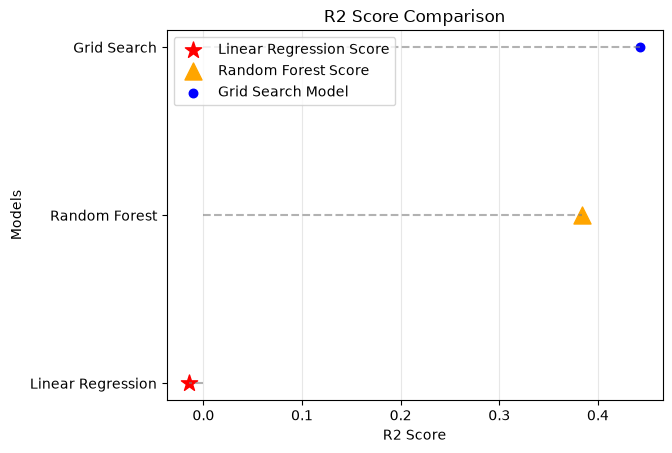

In [28]:
plt.hlines(y="Linear Regression", xmin=0, xmax=r2_score_linear_regression, color="gray", linestyle="--", alpha=0.6)
plt.hlines(y="Random Forest", xmin=0, xmax=r2_score_random_forest, color="gray", linestyle="--", alpha=0.6)
plt.hlines(y="Grid Search", xmin=0, xmax=r2_score_grid, color="gray", linestyle="--", alpha=0.6)

plt.scatter(r2_score_linear_regression, "Linear Regression", color="red", s=150, marker="*", label="Linear Regression Score")
plt.scatter(r2_score_random_forest, "Random Forest", color="orange", s=150, marker="^", label="Random Forest Score")
plt.scatter(r2_score_grid, "Grid Search", color="blue", s=150, marker=".", label="Grid Search Model")

plt.xlabel("R2 Score")
plt.ylabel("Models")
plt.title("R2 Score Comparison")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()